In [3]:
pip install pennylane tensorflow qiskit qiskit-aer quimb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 77.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 94.

In [4]:
## Importing libaries
## tensor flow keras  is used for the classiucal decoder for the this particular project
### numpy obsviously is used , mainly for the dimensionality of the storing array
#### pennylane for the Quantumn machine learnning , device and other parametres
##### quimb.tensor is mainly used for the importing the tensor network librarry and using tensor trains and mps and peps
##### CV2 is our open cv library usually used for collor encoding image to array conversion and flatteing
###### Qiskit our main simulator of the qbits and and importinf for the gates for amplitiude encoding
import tensorflow.keras
import numpy as pop
import cv2
import pennylane as qml
from pennylane import numpy as np
from qiskit import QuantumCircuit , transpile
from qiskit_aer import AerSimulator
import quimb.tensor as qtn
from tensorflow.keras import models , layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D , MaxPooling2D , Flatten , Activation , Dense , Dropout

##### IMAGE Preprocessing

In [6]:
##### IMAGE PREPERATION USING OPEN CV
## FIRST IMPORT the image and put it into a parametre

image = cv2.imread("/content/monalisa.jpg")
image = cv2.cvtColor(image , cv2.COLOR_BGR2GRAY) ### changes the colored monalisa photo to black and white photo and stores the respectve data ouput
size = 256
## now we wil rescale the image to 256 - 256 image
image = cv2.resize(image , (size , size))
image_data=[]
image_data.append(pop.array(image))
#print(image_data) ## Coverted the nested array to a nump array and the fed into a list
img_array = pop.reshape(image_data , (len(image_data) , size , size , 1))## reshapped the image_data to which is a 256*256 matrix to a 1 , 256 , 256 ,1 array
#print(img_array.shape)
img_array = img_array.astype('float32') ## changes the image arry values to float 32
img_array /= 255.0
img_array_flat = img_array.flatten()
print("The flatten image array in float 32 form is " , img_array_flat , img_array_flat.size, img_array_flat.shape);

## this img_array_flat is esssential the preprocessed image array that will enter into the mps compressor

The flatten image array in float 32 form is  [0.4117647  0.3019608  0.41568628 ... 0.03137255 0.07058824 0.26666668] 65536 (65536,)


##### MPS COMPRESSION AND RENORMALIZATION BEFORE AMPLITUDE ENCODING

In [7]:
## This img_data_flat is a float32 array witha size of 65536 and a shape of 65536 a single dimensional array containing 65536

img_array_flat = pop.asarray(img_array_flat).ravel()
img_array_flat = img_array_flat / pop.linalg.norm(img_array_flat) ### This is the linearly normalized data float32 matrix
#print(img_array_flat)
dimensions = [2]*16
mps = qtn.MatrixProductState.from_dense(img_array_flat , dims = dimensions)## encoding the the img_array_flat to mps_tensor
#print(mps)
mps.compress(max_bond = 64 , cutoff = 1e-8 )
#print(mps)

img_data_flat_mps_compressed = pop.asarray(mps.to_dense()).ravel()
img_data_flat_mps_compressed= img_data_flat_mps_compressed/(np.linalg.norm(img_data_flat_mps_compressed)+ 1e-12)
#print(img_data_flat_mps_compressed)
img_array_reconstructed = pop.asarray(mps.to_dense()).ravel()
error_while_reconstruction = (np.linalg.norm(img_data_flat_mps_compressed-img_array_reconstructed)/np.linalg.norm(img_data_flat_mps_compressed))
print("The relative reconstruction error fidelity is " , error_while_reconstruction*100,"%")




The relative reconstruction error fidelity is  0.20486708 %


#### PROCESSING OF DATA
##### Quantumn Amplitude Encoding using mps compressed image data

In [14]:
import pennylane as qml
from pennylane import numpy as np

n_qubits = 16
n_layers = 4

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def qae(weights, amplitudes):
    qml.AmplitudeEmbedding(amplitudes, wires=range(n_qubits), normalize=True)
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

amplitudes = np.array(img_data_flat_mps_compressed, requires_grad=False)

def cost_fn(weights):
    output = qae(weights, amplitudes)
    amp_target = amplitudes[:n_qubits]
    amp_loss = np.mean((np.array(output) - amp_target) ** 2)
    weight_loss = np.mean(weights ** 2)
    return amp_loss + 1e-3 * weight_loss

weights = 0.01 * np.random.randn(n_layers, n_qubits, 3, requires_grad=True)
optimizer = qml.AdamOptimizer(0.02)

for step in range(200):
    weights = optimizer.step(cost_fn, weights)
    if step % 20 == 0:
        print("Step", step, "Cost", cost_fn(weights))

print("Optimized weights:", weights)
latent = np.array(qae(weights, amplitudes), dtype=np.float32).reshape(1, n_qubits)
print("Latent shape:", latent.shape)


Step 0 Cost 1.710915793730767e-05
Step 20 Cost 7.63791097803449e-06
Step 40 Cost 6.935298118539508e-06
Step 60 Cost 6.829271602098577e-06
Step 80 Cost 6.819202354373599e-06
Step 100 Cost 6.8173034966165975e-06
Step 120 Cost 6.8170563630654466e-06
Step 140 Cost 6.81702743415212e-06
Step 160 Cost 6.817024220723181e-06
Step 180 Cost 6.817023773709354e-06
Optimized weights: [[[-3.25236341e-07  7.78886324e-02  3.10210024e-07]
  [ 8.25914043e-08  1.14179408e-02 -1.86021836e-08]
  [ 4.70206362e-08  1.00890714e-01 -1.04742274e-07]
  [ 5.30154665e-07 -3.03184436e-02 -6.09807210e-08]
  [-6.21469684e-08 -1.43665447e-01 -5.62570181e-08]
  [-1.24298986e-07  4.82011867e-02  2.14215846e-08]
  [-1.67635395e-07 -2.75824643e-04  1.21970884e-07]
  [ 4.16998223e-07  1.89291892e-01 -9.29898857e-08]
  [-5.43455858e-07 -1.10079187e-02 -5.03633696e-07]
  [ 6.67524028e-08  8.16828307e-02  4.86733750e-07]
  [-1.27651894e-07 -1.78028695e-03 -4.88344945e-08]
  [ 2.56081441e-07 -7.10185844e-03  2.18830717e-07]
  [

##### DECODING OF PROCESSED DATA

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - loss: 0.0808 - mae: 0.2435 - val_loss: 0.0808 - val_mae: 0.2434


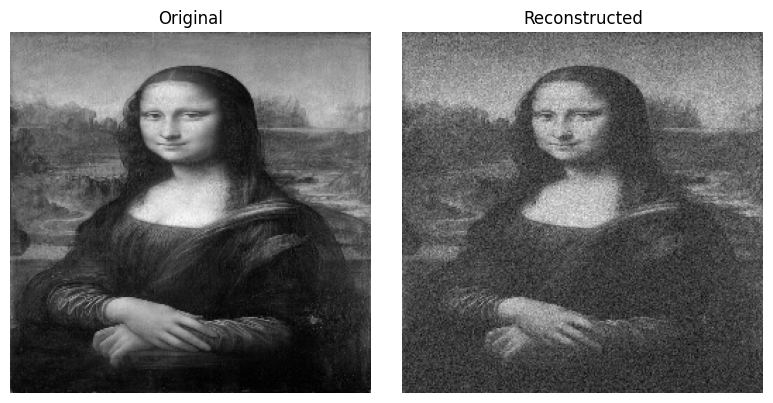

Decoder reconstruction MSE: 0.08078093826770782


In [ ]:
# Classical decoder and reconstruction
import matplotlib.pyplot as plt
from tensorflow.keras import models, layers

decoder = models.Sequential([
    layers.Input(shape=(n_qubits,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(512, activation="relu"),
    layers.Dense(2048, activation="relu"),
    layers.Dense(size * size, activation="sigmoid"),
    layers.Reshape((size, size, 1)),
])

decoder.compile(optimizer="adam", loss="mse", metrics=["mae"])

target = image.reshape(1, size, size, 1).astype("float32") / 255.0
history = decoder.fit(latent, target, epochs=1, verbose=1, validation_data=(latent, target))
pred = decoder.predict(latent, verbose=0)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(target[0, :, :, 0], cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Reconstructed")
plt.imshow(pred[0, :, :, 0], cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()

recon_mse = float(np.mean((target - pred) ** 2))
print("Decoder reconstruction MSE:", recon_mse)




Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 0.2489 - mae: 0.4989 - val_loss: 0.2480 - val_mae: 0.4980
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - loss: 0.2480 - mae: 0.4980 - val_loss: 0.2471 - val_mae: 0.4971
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - loss: 0.2471 - mae: 0.4971 - val_loss: 0.2462 - val_mae: 0.4962
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - loss: 0.2462 - mae: 0.4962 - val_loss: 0.2452 - val_mae: 0.4952
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - loss: 0.2452 - mae: 0.4952 - val_loss: 0.2442 - val_mae: 0.4941
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - loss: 0.2442 - mae: 0.4941 - val_loss: 0.2431 - val_mae: 0.4930
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - loss: 0.2431 - mae: 0.4930 - val_loss: 0.2419 - val_mae: 0.4918
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - loss: 0.2419 - mae: 0.4918 - val_loss: 0.2407 - val_mae: 0.4906
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - loss:

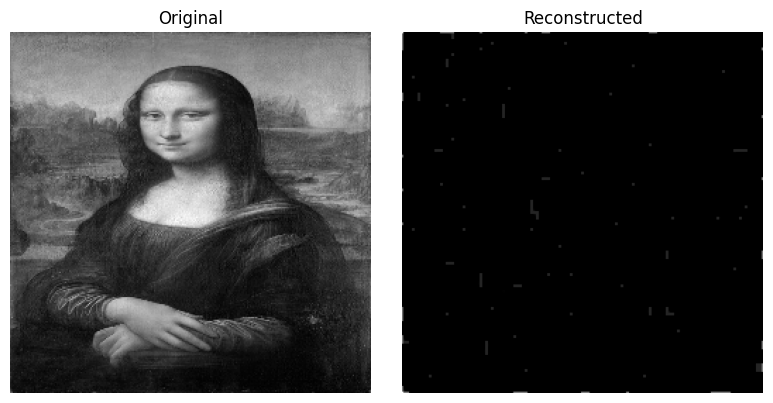

Decoder reconstruction MSE: 1.2073619473085273e-05


In [20]:
from tensorflow.keras import models, layers

decoder = models.Sequential([
    layers.Input(shape=(n_qubits,)),   # latent vector (e.g. 16)

    layers.Dense(64, activation="relu"),
    layers.Dense(256, activation="relu"),

    layers.Dense(4096, activation="relu"),   # 64 × 64
    layers.Reshape((64, 64, 1)),

    layers.UpSampling2D((2,2)),   # 128 × 128
    layers.Conv2D(16, 3, padding="same", activation="relu"),

    layers.UpSampling2D((2,2)),   # 256 × 256
    layers.Conv2D(1, 3, padding="same", activation="sigmoid")
])
decoder.compile(optimizer="adam", loss="mse", metrics=["mae"])

target = image.reshape(1, size, size, 1).astype("float32") / 255.0
history = decoder.fit(latent, target, epochs=1000, verbose=1, validation_data=(latent, target))
pred = decoder.predict(latent, verbose=0)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(target[0, :, :, 0], cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Reconstructed")
plt.imshow(pred[0, :, :, 0], cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()

recon_mse = float(np.mean((target - pred) ** 2))
print("Decoder reconstruction MSE:", recon_mse)

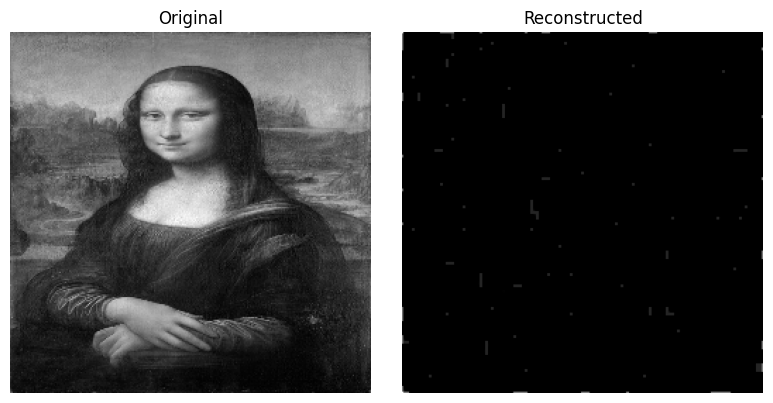

Decoder reconstruction MSE: 1.2073619473085273e-05


In [21]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(target[0, :, :, 0], cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Reconstructed")
plt.imshow(pred[0, :, :, 0], cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()

recon_mse = float(np.mean((target - pred) ** 2))
print("Decoder reconstruction MSE:", recon_mse)

Relative reconstruction error: 0.0640057425
State fidelity:               0.9959074607


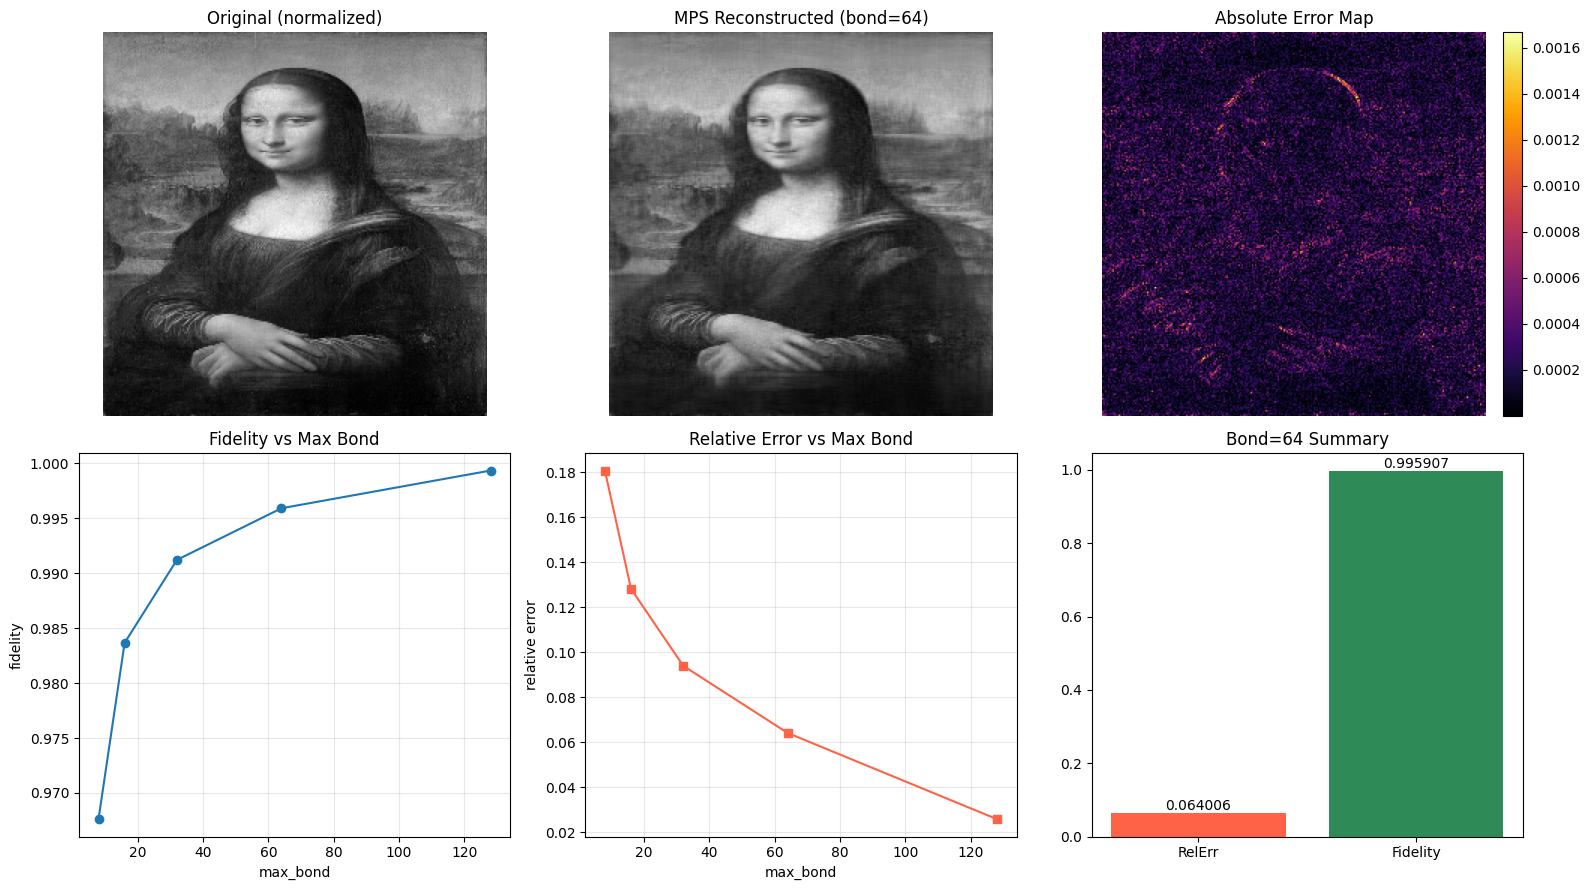

In [ ]:


import numpy as np
import matplotlib.pyplot as plt
import quimb.tensor as qtn
x_true = np.asarray(img_array_flat).ravel().astype(np.float64)
x_true = x_true / (np.linalg.norm(x_true) + 1e-12)

n_qubits = 16
dims = [2] * n_qubits

if x_true.size != 2**n_qubits:
    raise ValueError(f"x_true size = {x_true.size}, expected {2**n_qubits} for {n_qubits} qubits.")

def mps_reconstruct_metrics(x, max_bond=64, cutoff=1e-8):
    mps = qtn.MatrixProductState.from_dense(x, dims=dims)
    mps.compress(max_bond=max_bond, cutoff=cutoff)

    x_rec = np.asarray(mps.to_dense()).ravel().astype(np.float64)
    x_rec = x_rec / (np.linalg.norm(x_rec) + 1e-12)

    rel_err = np.linalg.norm(x - x_rec) / (np.linalg.norm(x) + 1e-12)
    fidelity = np.abs(np.vdot(x, x_rec))**2
    return x_rec, float(rel_err), float(fidelity)

x_rec, rel_err, fidelity = mps_reconstruct_metrics(x_true, max_bond=64, cutoff=1e-8)

print(f"Relative reconstruction error: {rel_err:.10f}")
print(f"State fidelity:               {fidelity:.10f}")

bond_dims = [8, 16, 32, 64, 128]
errs, fids = [], []

for b in bond_dims:
    _, e, f = mps_reconstruct_metrics(x_true, max_bond=b, cutoff=1e-8)
    errs.append(e)
    fids.append(f)


n = int(np.sqrt(x_true.size))  # 256 for 16 qubits
img_true = x_true.reshape(n, n)
img_rec  = x_rec.reshape(n, n)
err_map  = np.abs(img_true - img_rec)


fig, ax = plt.subplots(2, 3, figsize=(16, 9))

ax[0, 0].imshow(img_true, cmap="gray")
ax[0, 0].set_title("Original (normalized)")
ax[0, 0].axis("off")

ax[0, 1].imshow(img_rec, cmap="gray")
ax[0, 1].set_title("MPS Reconstructed (bond=64)")
ax[0, 1].axis("off")

im = ax[0, 2].imshow(err_map, cmap="inferno")
ax[0, 2].set_title("Absolute Error Map")
ax[0, 2].axis("off")
plt.colorbar(im, ax=ax[0, 2], fraction=0.046, pad=0.04)

ax[1, 0].plot(bond_dims, fids, marker="o")
ax[1, 0].set_title("Fidelity vs Max Bond")
ax[1, 0].set_xlabel("max_bond")
ax[1, 0].set_ylabel("fidelity")
ax[1, 0].grid(alpha=0.3)

ax[1, 1].plot(bond_dims, errs, marker="s", color="tomato")
ax[1, 1].set_title("Relative Error vs Max Bond")
ax[1, 1].set_xlabel("max_bond")
ax[1, 1].set_ylabel("relative error")
ax[1, 1].grid(alpha=0.3)

metric_names = ["RelErr", "Fidelity"]
metric_vals = [rel_err, fidelity]
bars = ax[1, 2].bar(metric_names, metric_vals, color=["tomato", "seagreen"])
ax[1, 2].set_title("Bond=64 Summary")
for b, v in zip(bars, metric_vals):
    ax[1, 2].text(b.get_x() + b.get_width()/2, b.get_height(), f"{v:.6f}",
                  ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


## EXTRA PARTS

In [ ]:
!pip install scikit-image


MSE  : 0.08078094
MAE  : 0.24339020
PSNR : 10.927 dB
SSIM : 0.27827

Decoder input test (lower is better):
MSE(true latent)   : 0.08078093826770782
MSE(shuffled latent): 0.08078093826770782
MSE(zero latent)   : 0.08078118413686752
MSE(random latent) : 0.08080616593360901


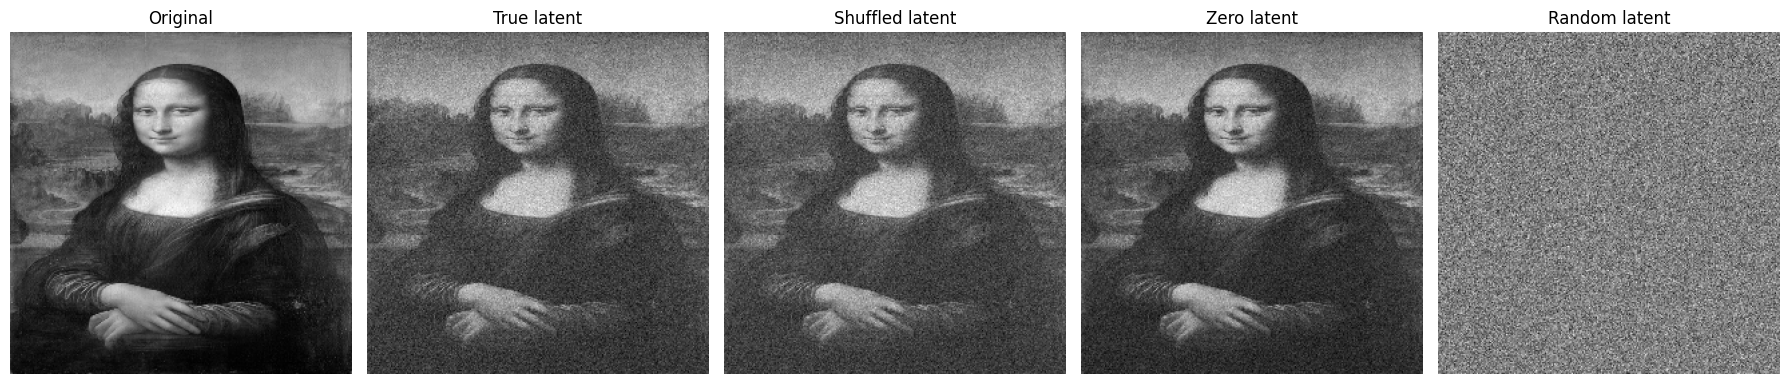

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# -----------------------------
# 1) Quality metrics
# -----------------------------
y_true = target[0, :, :, 0]
y_pred = pred[0, :, :, 0]

mse = np.mean((y_true - y_pred) ** 2)
mae = np.mean(np.abs(y_true - y_pred))
psnr = peak_signal_noise_ratio(y_true, y_pred, data_range=1.0)
ssim = structural_similarity(y_true, y_pred, data_range=1.0)

print(f"MSE  : {mse:.8f}")
print(f"MAE  : {mae:.8f}")
print(f"PSNR : {psnr:.3f} dB")
print(f"SSIM : {ssim:.5f}")

# -----------------------------
# 2) Latent dependence test
# -----------------------------
z_true = latent.copy()
z_zero = np.zeros_like(latent)
z_rand = np.random.randn(*latent.shape).astype(np.float32)
z_shuffle = latent[:, np.random.permutation(latent.shape[1])]

pred_true = decoder.predict(z_true, verbose=0)
pred_zero = decoder.predict(z_zero, verbose=0)
pred_rand = decoder.predict(z_rand, verbose=0)
pred_shuffle = decoder.predict(z_shuffle, verbose=0)

def img_mse(x): return np.mean((target - x) ** 2)

print("\nDecoder input test (lower is better):")
print("MSE(true latent)   :", float(img_mse(pred_true)))
print("MSE(shuffled latent):", float(img_mse(pred_shuffle)))
print("MSE(zero latent)   :", float(img_mse(pred_zero)))
print("MSE(random latent) :", float(img_mse(pred_rand)))

# -----------------------------
# 3) PPT figure (easy to show)
# -----------------------------
fig, ax = plt.subplots(1, 5, figsize=(18, 4))
ax[0].imshow(y_true, cmap="gray"); ax[0].set_title("Original"); ax[0].axis("off")
ax[1].imshow(pred_true[0,:,:,0], cmap="gray"); ax[1].set_title("True latent"); ax[1].axis("off")
ax[2].imshow(pred_shuffle[0,:,:,0], cmap="gray"); ax[2].set_title("Shuffled latent"); ax[2].axis("off")
ax[3].imshow(pred_zero[0,:,:,0], cmap="gray"); ax[3].set_title("Zero latent"); ax[3].axis("off")
ax[4].imshow(pred_rand[0,:,:,0], cmap="gray"); ax[4].set_title("Random latent"); ax[4].axis("off")
plt.tight_layout()
plt.show()


Dataset shape: (12, 256, 256)
Amplitude dataset: (12, 65536)
Mean MPS relative error: 0.06029191727856745
Step 0 Cost 0.16396514542843135
Step 20 Cost 0.001589686445289952
Step 40 Cost 0.0002555412937312924
Step 60 Cost 4.243737493569131e-05
Step 80 Cost 7.995777802478815e-06
Step 100 Cost 4.490265213460654e-06
Step 120 Cost 3.8455209856286146e-06
Step 140 Cost 3.773242954084651e-06
Step 160 Cost 3.7520013804034703e-06
Step 180 Cost 3.7389786774311497e-06
Final encoder cost: 3.7260534141183127e-06
X_latent: (12, 16) Y_img: (12, 256, 256, 1)
Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - loss: 0.0826 - mae: 0.2466 - val_loss: 0.0808 - val_mae: 0.2434
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - loss: 0.0847 - mae: 0.2502 - val_loss: 0.0806 - val_mae: 0.2431
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 0.0821 - mae: 0.2462 - val_loss: 0.0804 - val_mae: 0.2428
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - loss: 0.0786 - mae: 0.2404 - val_loss: 0.0802 - val_mae: 0.24

KeyboardInterrupt: 

Dataset shape: (200, 256, 256)
Compressed dataset shape: (200, 65536)
Latent shape: (200, 16)
Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 720ms/step - loss: 0.0878
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 605ms/step - loss: 0.0808
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 619ms/step - loss: 0.0698
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 693ms/step - loss: 0.0534
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 891ms/step - loss: 0.0296
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 753ms/step - loss: 0.0235
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - loss: 0.0208
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - loss: 0.0199
Epoch 9/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 836ms/step - loss: 0.0187
Epoch 10/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 591ms/step - loss: 0.0178
Epoch 11/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 680ms/step - loss: 0.0175
Epoch 12/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 712ms/step - loss: 0.0174
Epoch 13/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 663ms/step - loss: 0.0168
Epoch 14/20
13/13 ━━━━━━━━━

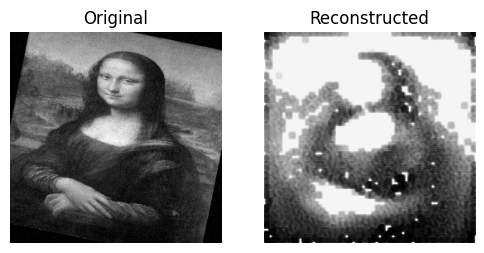

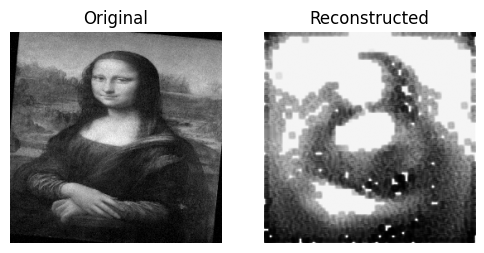

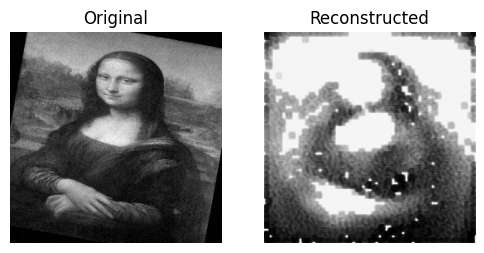

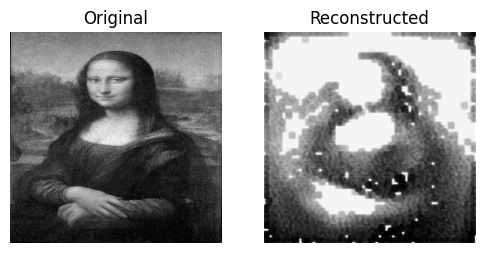

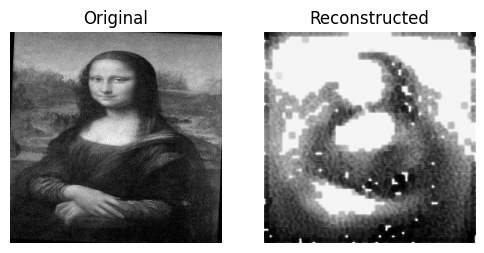

Reconstruction MSE: 0.014543192


In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import quimb.tensor as qtn
import pennylane as qml
from tensorflow.keras import models, layers

############################################
# 1 LOAD MONA LISA
############################################

image_path = "/content/monalisa.jpg"

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

size = 256
img = cv2.resize(img,(size,size))

############################################
# 2 DATA AUGMENTATION
############################################

dataset = []

for i in range(200):

    angle = np.random.uniform(-15,15)

    M = cv2.getRotationMatrix2D((size/2,size/2),angle,1)

    rotated = cv2.warpAffine(img,M,(size,size))

    noise = np.random.normal(0,5,(size,size))

    augmented = rotated + noise

    augmented = np.clip(augmented,0,255)

    dataset.append(augmented)

dataset = np.array(dataset).astype("float32")/255.0

print("Dataset shape:",dataset.shape)

############################################
# 3 FLATTEN
############################################

dataset_flat = dataset.reshape(len(dataset),-1)

dataset_flat = dataset_flat / np.linalg.norm(dataset_flat,axis=1,keepdims=True)

############################################
# 4 MPS COMPRESSION (FIXED)
############################################

dims = [2]*16

mps_dataset = []

for vec in dataset_flat:

    vec = vec.flatten()
    vec = vec / np.linalg.norm(vec)

    mps = qtn.MatrixProductState.from_dense(vec,dims=dims)

    mps.compress(max_bond=64,cutoff=1e-8)

    compressed = mps.to_dense()

    compressed = np.array(compressed).flatten()

    compressed = compressed / np.linalg.norm(compressed)

    mps_dataset.append(compressed)

mps_dataset = np.array(mps_dataset)

print("Compressed dataset shape:",mps_dataset.shape)

############################################
# 5 QUANTUM ENCODER
############################################

n_qubits = 16
n_layers = 4

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)

def qae(weights, amplitudes):

    qml.AmplitudeEmbedding(
        amplitudes,
        wires=range(n_qubits),
        normalize=True
    )

    qml.StronglyEntanglingLayers(
        weights,
        wires=range(n_qubits)
    )

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

############################################
# 6 LATENT GENERATION
############################################

weights = 0.01*np.random.randn(n_layers,n_qubits,3)

latent_dataset = []

for vec in mps_dataset:

    latent = qae(weights,vec)

    latent_dataset.append(latent)

latent_dataset = np.array(latent_dataset)

print("Latent shape:",latent_dataset.shape)

############################################
# 7 DECODER
############################################

decoder = models.Sequential([

    layers.Input(shape=(n_qubits,)),

    layers.Dense(64,activation="relu"),
    layers.Dense(256,activation="relu"),

    layers.Dense(4096,activation="relu"),

    layers.Reshape((64,64,1)),

    layers.UpSampling2D((2,2)),
    layers.Conv2D(16,3,padding="same",activation="relu"),

    layers.UpSampling2D((2,2)),
    layers.Conv2D(1,3,padding="same",activation="sigmoid")

])

decoder.compile(
    optimizer="adam",
    loss="mse"
)

############################################
# 8 TRAIN
############################################

decoder.fit(
    latent_dataset,
    dataset.reshape(len(dataset),256,256,1),
    epochs=20,
    batch_size=16
)

############################################
# 9 TEST
############################################

pred = decoder.predict(latent_dataset[:5])

for i in range(5):

    plt.figure(figsize=(6,3))

    plt.subplot(1,2,1)
    plt.title("Original")
    plt.imshow(dataset[i],cmap="gray")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Reconstructed")
    plt.imshow(pred[i].reshape(256,256),cmap="gray")
    plt.axis("off")

    plt.show()

############################################
# 10 MSE
############################################

mse = np.mean((dataset[:5] - pred.reshape(5,256,256))**2)

print("Reconstruction MSE:",mse)

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import quimb.tensor as qtn

bond_dims = [4,8,16,32,64 , 128 , 256]

mse_results = []

for chi in bond_dims:

    print("Testing bond dimension:",chi)

    mps_dataset = []

    for vec in dataset_flat:

        vec = vec.flatten()
        vec = vec/np.linalg.norm(vec)

        mps = qtn.MatrixProductState.from_dense(vec,dims=[2]*16)

        mps.compress(max_bond=chi,cutoff=1e-8)

        compressed = mps.to_dense()

        compressed = np.array(compressed).flatten()
        compressed = compressed/np.linalg.norm(compressed)

        mps_dataset.append(compressed)

    mps_dataset = np.array(mps_dataset)

    ########################################
    # Generate quantum latent vectors
    ########################################

    latent_dataset = []

    for vec in mps_dataset:

        latent = qae(weights,vec)

        latent_dataset.append(latent)

    latent_dataset = np.array(latent_dataset)

    ########################################
    # Train decoder briefly
    ########################################

    decoder.fit(
        latent_dataset,
        dataset.reshape(len(dataset),256,256,1),
        epochs=5,
        batch_size=16,
        verbose=0
    )

    pred = decoder.predict(latent_dataset)

    mse = np.mean((dataset - pred.reshape(len(dataset),256,256))**2)

    mse_results.append(mse)

    print("MSE:",mse)

Testing bond dimension: 2
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 600ms/step
MSE: 0.015557509
Testing bond dimension: 4


KeyboardInterrupt: 

ValueError: x and y must have same first dimension, but have shapes (6,) and (1,)

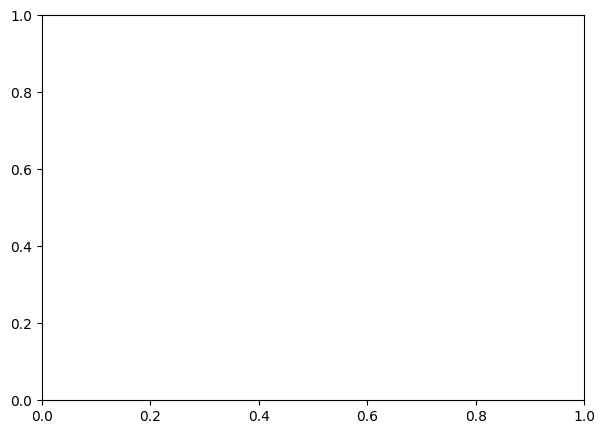

In [13]:
plt.figure(figsize=(7,5))

plt.plot(bond_dims,mse_results,'o-',linewidth=2)

plt.xlabel("MPS Bond Dimension (χ)")
plt.ylabel("Reconstruction MSE")

plt.title("Reconstruction Error vs MPS Bond Dimension")

plt.grid(True)

plt.show()

In [ ]:

psnr = 10*np.log10(1/mse_results)
plt.figure(figsize=(7,5))

plt.plot(bond_dims,psnr,'o-',linewidth=2)

plt.xlabel("Peak SIgnal To noise ratio ")
plt.ylabel("Reconstruction MSE")

plt.title("Reconstruction Error vs MPS Bond Dimension")

plt.grid(True)

plt.show()
print(psnr)

Image shape: (256, 256)
Flatten size: 65536
Compressed vector size: (65536,)
Latent vector shape: (1, 16)
Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 0.0809
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 0.0805
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - loss: 0.0801
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 0.0797
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0793
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 0.0788
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.0784
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0779
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - loss: 0.0774
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 0.0769
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0764
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - loss: 0.0759
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0753
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━

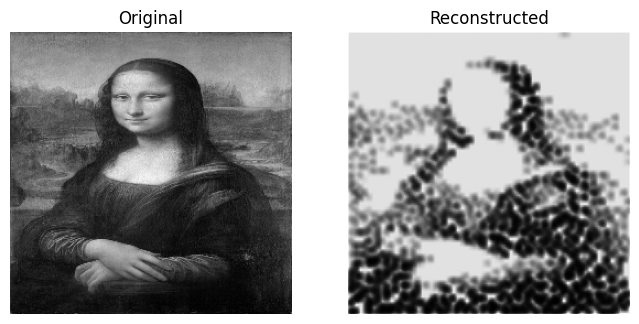

Reconstruction MSE: 0.013255637


In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import quimb.tensor as qtn
import pennylane as qml
from tensorflow.keras import models, layers

############################################
# 1 LOAD MONA LISA
############################################

image_path = "/content/monalisa.jpg"

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

size = 256
img = cv2.resize(img,(size,size))

img = img.astype("float32")/255.0

print("Image shape:",img.shape)

############################################
# 2 FLATTEN IMAGE
############################################

img_flat = img.flatten()

img_flat = img_flat / np.linalg.norm(img_flat)

print("Flatten size:",len(img_flat))

############################################
# 3 MPS COMPRESSION
############################################

dims = [2]*16   # 2^16 = 65536

mps = qtn.MatrixProductState.from_dense(img_flat,dims=dims)

mps.compress(max_bond=64,cutoff=1e-8)

compressed = mps.to_dense()

compressed = np.array(compressed).flatten()

compressed = compressed / np.linalg.norm(compressed)

print("Compressed vector size:",compressed.shape)

############################################
# 4 QUANTUM ENCODER
############################################

n_qubits = 16
n_layers = 4

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)

def qae(weights, amplitudes):

    qml.AmplitudeEmbedding(
        amplitudes,
        wires=range(n_qubits),
        normalize=True
    )

    qml.StronglyEntanglingLayers(
        weights,
        wires=range(n_qubits)
    )

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

############################################
# 5 GENERATE LATENT VECTOR
############################################

weights = 0.01*np.random.randn(n_layers,n_qubits,3)

latent = qae(weights,compressed)

latent = np.array(latent).reshape(1,n_qubits)

print("Latent vector shape:",latent.shape)

############################################
# 6 DECODER
############################################

decoder = models.Sequential([

    layers.Input(shape=(n_qubits,)),

    layers.Dense(64,activation="relu"),
    layers.Dense(256,activation="relu"),

    layers.Dense(4096,activation="relu"),

    layers.Reshape((64,64,1)),

    layers.UpSampling2D((2,2)),
    layers.Conv2D(16,3,padding="same",activation="relu"),

    layers.UpSampling2D((2,2)),
    layers.Conv2D(1,3,padding="same",activation="sigmoid")

])

decoder.compile(
    optimizer="adam",
    loss="mse"
)

############################################
# 7 TRAIN DECODER
############################################

target = img.reshape(1,256,256,1)

decoder.fit(
    latent,
    target,
    epochs=100,
    verbose=1
)

############################################
# 8 RECONSTRUCTION
############################################

pred = decoder.predict(latent)

############################################
# 9 DISPLAY RESULTS
############################################

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img,cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Reconstructed")
plt.imshow(pred[0].reshape(256,256),cmap="gray")
plt.axis("off")

plt.show()

############################################
# 10 RECONSTRUCTION ERROR
############################################

mse = np.mean((img - pred.reshape(256,256))**2)

print("Reconstruction MSE:",mse)

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import quimb.tensor as qtn
import pennylane as qml
import tensorflow as tf
from tensorflow.keras import layers, models

############################################
# 1 LOAD IMAGE
############################################

img = cv2.imread("/content/monalisa.jpg", cv2.IMREAD_GRAYSCALE)

size = 256
img = cv2.resize(img,(size,size))
img = img.astype("float32")/255.0

############################################
# 2 FLATTEN
############################################

vec = img.flatten()
vec = vec / np.linalg.norm(vec)

############################################
# 3 MPS COMPRESSION
############################################

dims = [2]*16

mps = qtn.MatrixProductState.from_dense(vec,dims=dims)

mps.compress(max_bond=64,cutoff=1e-8)

compressed = np.array(mps.to_dense()).flatten()
compressed = compressed / np.linalg.norm(compressed)

############################################
# 4 QUANTUM ENCODER
############################################

n_qubits = 16
n_layers = 4

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="autograd")

def encoder(weights, x):

    qml.AmplitudeEmbedding(x, wires=range(n_qubits), normalize=True)

    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

############################################
# 5 DECODER
############################################

decoder = models.Sequential([

    layers.Input(shape=(n_qubits,)),

    layers.Dense(128,activation="relu"),
    layers.Dense(512,activation="relu"),

    layers.Dense(4096,activation="relu"),

    layers.Reshape((64,64,1)),

    layers.UpSampling2D((2,2)),
    layers.Conv2D(16,3,padding="same",activation="relu"),

    layers.UpSampling2D((2,2)),
    layers.Conv2D(1,3,padding="same",activation="sigmoid")

])

optimizer = tf.keras.optimizers.Adam(0.01)

############################################
# 6 TRAINING SETUP
############################################

weights = np.random.randn(n_layers,n_qubits,3)*0.01

target = img.reshape(1,256,256,1)

epochs = 200

loss_history = []

############################################
# 7 TRAIN LOOP
############################################

for step in range(epochs):

    with tf.GradientTape() as tape:

        latent = encoder(weights, compressed)
        latent = tf.convert_to_tensor([latent],dtype=tf.float32)

        reconstruction = decoder(latent)

        loss = tf.reduce_mean((reconstruction-target)**2)

    grads = tape.gradient(loss, decoder.trainable_variables)

    optimizer.apply_gradients(zip(grads, decoder.trainable_variables))

    # update quantum weights manually
    weights = weights - 0.01 * qml.grad(lambda w: np.mean(
        (decoder(np.array([encoder(w,compressed)])) - target)**2
    ))(weights)

    loss_history.append(loss.numpy())

    if step % 20 == 0:
        print("Step",step,"Loss",loss.numpy())

############################################
# 8 RECONSTRUCTION
############################################

latent = encoder(weights,compressed)
pred = decoder.predict(np.array([latent]))

############################################
# 9 DISPLAY
############################################

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img,cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Reconstructed")
plt.imshow(pred[0].reshape(256,256),cmap="gray")
plt.axis("off")

plt.show()

############################################
# 10 LOSS CURVE
############################################

plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.show()

/usr/local/lib/python3.12/dist-packages/pennylane/_grad/grad.py:337: UserWarning: Attempted to differentiate a function with no trainable parameters. If this is unintended, please add trainable parameters via the 'requires_grad' attribute or 'argnums' keyword.
  warnings.warn(


TypeError: can't multiply sequence by non-int of type 'float'